In [1]:
using Oceananigans
using Oceananigans.Units

using CairoMakie
using CUDA
using Printf
using Random
using SeawaterPolynomials.TEOS10: TEOS10EquationOfState

Random.seed!(1969) # for reproducible results

┌ Warning: You are using a non-official build of Julia. This may cause issues with CUDA.jl.
│ Please consider using an official build from https://julialang.org/downloads/.
└ @ CUDA ~/Desktop/deletar/intro2modelsNEU/.pixi/envs/default/share/julia/packages/CUDA/Il00B/src/initialization.jl:164


TaskLocalRNG()

In [2]:
Nx = Ny = 1    # number of points in each of horizontal directions
Nz = 64          # number of points in the vertical direction

Lx = Ly = 1    # (m) domain horizontal extents
Lz = 128          # (m) domain depth

refinement = 1.2 # controls spacing near surface (higher means finer spaced)
stretching = 12  # controls rate of stretching at bottom

# Normalized height ranging from 0 to 1
h(k) = (k - 1) / Nz

# Linear near-surface generator
ζ₀(k) = 1 + (h(k) - 1) / refinement

# Bottom-intensified stretching function
Σ(k) = (1 - exp(-stretching * h(k))) / (1 - exp(-stretching))

# Generating function
z_interfaces(k) = Lz * (ζ₀(k) * Σ(k) - 1)

grid = RectilinearGrid(CPU(),
                       topology = (Flat, Flat, Bounded),
                       size = (Nz,),
                       # x = (0, Lx),
                       # y = (0, Ly),
                       z = z_interfaces)

1×1×64 RectilinearGrid{Float64, Flat, Flat, Bounded} on CPU with 0×0×3 halo
├── Flat x                    
├── Flat y                    
└── Bounded  z ∈ [-64.0, 0.0] variably spaced with min(Δz)=0.833413, max(Δz)=1.96618

In [3]:
ρₒ = 1026 # kg m⁻³, average density at the surface of the world ocean
equation_of_state = TEOS10EquationOfState(reference_density=ρₒ)
buoyancy = SeawaterBuoyancy(; equation_of_state)

SeawaterBuoyancy{Float64}:
├── gravitational_acceleration: 9.80665
└── equation_of_state: BoussinesqEquationOfState{Float64}

In [4]:
Q = 200   # W m⁻², surface _heat_ flux
cᴾ = 3991 # J K⁻¹ kg⁻¹, typical heat capacity for seawater

Jᵀ = Q / (ρₒ * cᴾ) # K m s⁻¹, surface _temperature_ flux

4.884283985946938e-5

In [5]:
dTdz = 0.01 # K m⁻¹

T_bcs = FieldBoundaryConditions(top = FluxBoundaryCondition(Jᵀ),
                                bottom = GradientBoundaryCondition(dTdz))

Oceananigans.FieldBoundaryConditions, with boundary conditions
├── west: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)
├── east: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)
├── south: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)
├── north: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)
├── bottom: GradientBoundaryCondition: 0.01
├── top: FluxBoundaryCondition: 4.88428e-5
└── immersed: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)

In [6]:
u₁₀ = 10  # m s⁻¹, average wind velocity 10 meters above the ocean
cᴰ = 2e-3 # dimensionless drag coefficient
ρₐ = 1.2  # kg m⁻³, approximate average density of air at sea-level
τx = - ρₐ / ρₒ * cᴰ * u₁₀ * abs(u₁₀) # m² s⁻²

-0.00023391812865497074

In [7]:
u_bcs = FieldBoundaryConditions(top = FluxBoundaryCondition(τx))

Oceananigans.FieldBoundaryConditions, with boundary conditions
├── west: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)
├── east: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)
├── south: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)
├── north: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)
├── bottom: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)
├── top: FluxBoundaryCondition: -0.000233918
└── immersed: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)

In [8]:
@inline Jˢ(t, S, evaporation_rate) = - evaporation_rate * S # [salinity unit] m s⁻¹

Jˢ (generic function with 1 method)

In [9]:
evaporation_rate = 1e-3 / hour # m s⁻¹

2.7777777777777776e-7

In [10]:
evaporation_bc = FluxBoundaryCondition(Jˢ, field_dependencies=:S, parameters=evaporation_rate)

FluxBoundaryCondition: ContinuousBoundaryFunction Jˢ at (Nothing, Nothing, Nothing)

In [11]:
S_bcs = FieldBoundaryConditions(top=evaporation_bc)

Oceananigans.FieldBoundaryConditions, with boundary conditions
├── west: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)
├── east: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)
├── south: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)
├── north: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)
├── bottom: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)
├── top: FluxBoundaryCondition: ContinuousBoundaryFunction Jˢ at (Nothing, Nothing, Nothing)
└── immersed: DefaultBoundaryCondition (FluxBoundaryCondition: Nothing)

In [12]:
model = HydrostaticFreeSurfaceModel(grid; buoyancy,
                            # advection = WENO(order=7),
                            tracers = (:T, :S),
                            coriolis = FPlane(f=1e-4),
                            closure = CATKEVerticalDiffusivity(),
                            boundary_conditions = (u=u_bcs, T=T_bcs, S=S_bcs))

HydrostaticFreeSurfaceModel{CPU, RectilinearGrid}(time = 0 seconds, iteration = 0)
├── grid: 1×1×64 RectilinearGrid{Float64, Flat, Flat, Bounded} on CPU with 0×0×3 halo
├── timestepper: QuasiAdamsBashforth2TimeStepper
├── tracers: (T, S, e)
├── closure: CATKEVerticalDiffusivity{VerticallyImplicitTimeDiscretization}
├── buoyancy: SeawaterBuoyancy with g=9.80665 and BoussinesqEquationOfState{Float64} with ĝ = NegativeZDirection()
├── advection scheme: 
│   ├── momentum: VectorInvariant
│   ├── T: Centered(order=2)
│   ├── S: Centered(order=2)
│   └── e: Centered(order=2)
├── vertical_coordinate: ZCoordinate
└── coriolis: FPlane{Float64}

In [13]:
# Random noise damped at top and bottom
Ξ(z) = randn() * z / model.grid.Lz * (1 + z / model.grid.Lz) # noise

# Temperature initial condition: a stable density gradient with random noise superposed.
Tᵢ(z) = 20 + dTdz * z + dTdz * model.grid.Lz * 2e-6 * Ξ(z)

# Velocity initial condition: random noise scaled by the friction velocity.
uᵢ(z) = sqrt(abs(τx)) * 1e-3 * Ξ(z)

# `set!` the `model` fields using functions or constants:
set!(model, u=uᵢ, T=Tᵢ, S=35)

In [14]:
simulation = Simulation(model, Δt=10, stop_time=2hours)

Simulation of HydrostaticFreeSurfaceModel{CPU, RectilinearGrid}(time = 0 seconds, iteration = 0)
├── Next time step: 10 seconds
├── run_wall_time: 0 seconds
├── run_wall_time / iteration: NaN days
├── stop_time: 2 hours
├── stop_iteration: Inf
├── wall_time_limit: Inf
├── minimum_relative_step: 0.0
├── callbacks: OrderedDict with 4 entries:
│   ├── stop_time_exceeded => Callback of stop_time_exceeded on IterationInterval(1)
│   ├── stop_iteration_exceeded => Callback of stop_iteration_exceeded on IterationInterval(1)
│   ├── wall_time_limit_exceeded => Callback of wall_time_limit_exceeded on IterationInterval(1)
│   └── nan_checker => Callback of NaNChecker for u on IterationInterval(100)
└── output_writers: OrderedDict with no entries

In [15]:
conjure_time_step_wizard!(simulation, cfl=0.7)

In [16]:
model

HydrostaticFreeSurfaceModel{CPU, RectilinearGrid}(time = 0 seconds, iteration = 0)
├── grid: 1×1×64 RectilinearGrid{Float64, Flat, Flat, Bounded} on CPU with 0×0×3 halo
├── timestepper: QuasiAdamsBashforth2TimeStepper
├── tracers: (T, S, e)
├── closure: CATKEVerticalDiffusivity{VerticallyImplicitTimeDiscretization}
├── buoyancy: SeawaterBuoyancy with g=9.80665 and BoussinesqEquationOfState{Float64} with ĝ = NegativeZDirection()
├── advection scheme: 
│   ├── momentum: VectorInvariant
│   ├── T: Centered(order=2)
│   ├── S: Centered(order=2)
│   └── e: Centered(order=2)
├── vertical_coordinate: ZCoordinate
└── coriolis: FPlane{Float64}

In [17]:
# Create a NamedTuple with eddy viscosity
diffusivities = (; model.closure_fields.κu, model.closure_fields.κc)
velocities = (; model.velocities.u, model.velocities.v)


filename = "ocean_wind_mixing_and_convection"

simulation.output_writers[:slices] =
    JLD2Writer(model, merge(velocities, model.tracers,  diffusivities),
               filename = filename * ".jld2",
               # indices = (:, grid.Ny/2, :),
               schedule = TimeInterval(1minute),
               overwrite_existing = true)

JLD2Writer scheduled on TimeInterval(1 minute):
├── filepath: ocean_wind_mixing_and_convection.jld2
├── 7 outputs: (u, v, T, S, e, κu, κc)
├── array_type: Array{Float32}
├── including: [:grid, :coriolis, :buoyancy, :closure]
├── file_splitting: NoFileSplitting
└── file size: 0 bytes (file not yet created)

In [18]:
# Print a progress message
progress_message(sim) = @printf("Iteration: %04d, time: %s, Δt: %s, max(|w|) = %.1e ms⁻¹, wall time: %s\n",
                                iteration(sim), prettytime(sim), prettytime(sim.Δt),
                                maximum(abs, sim.model.velocities.u), prettytime(sim.run_wall_time))

add_callback!(simulation, progress_message, IterationInterval(200))

In [19]:
run!(simulation)

[ Info: Initializing simulation...


Iteration: 0000, time: 0 seconds, Δt: 11 seconds, max(|w|) = 5.8e-06 ms⁻¹, wall time: 0 seconds


[ Info:     ... simulation initialization complete (12.958 seconds)
[ Info: Executing initial time step...
[ Info:     ... initial time step complete (15.032 seconds).


Iteration: 0200, time: 1.383 hours, Δt: 1.233 minutes, max(|w|) = 1.4e-01 ms⁻¹, wall time: 28.968 seconds


[ Info: Simulation is stopping after running for 29.373 seconds.
[ Info: Simulation time 2 hours equals or exceeds stop time 2 hours.


In [20]:
filepath = filename * ".jld2"
time_series = (u  = FieldTimeSeries(filepath, "u"),
               v  = FieldTimeSeries(filepath, "v"),
               T  = FieldTimeSeries(filepath, "T"),
               S  = FieldTimeSeries(filepath, "S"),
               κu = FieldTimeSeries(filepath, "κu"),
               κc = FieldTimeSeries(filepath, "κc"))

(u = 1×1×64×121 FieldTimeSeries{InMemory} located at (Face, Center, Center) of u at ocean_wind_mixing_and_convection.jld2
├── grid: 1×1×64 RectilinearGrid{Float64, Flat, Flat, Bounded} on CPU with 0×0×3 halo
├── indices: (:, :, :)
├── time_indexing: Linear()
├── backend: InMemory()
├── path: ocean_wind_mixing_and_convection.jld2
├── name: u
└── data: 1×1×70×121 OffsetArray(::Array{Float64, 4}, 1:1, 1:1, -2:67, 1:121) with eltype Float64 with indices 1:1×1:1×-2:67×1:121
    └── max=0.152051, min=-4.68704e-6, mean=0.0154345, v = 1×1×64×121 FieldTimeSeries{InMemory} located at (Center, Face, Center) of v at ocean_wind_mixing_and_convection.jld2
├── grid: 1×1×64 RectilinearGrid{Float64, Flat, Flat, Bounded} on CPU with 0×0×3 halo
├── indices: (:, :, :)
├── time_indexing: Linear()
├── backend: InMemory()
├── path: ocean_wind_mixing_and_convection.jld2
├── name: v
└── data: 1×1×70×121 OffsetArray(::Array{Float64, 4}, 1:1, 1:1, -2:67, 1:121) with eltype Float64 with indices 1:1×1:1×-2:67×1:12

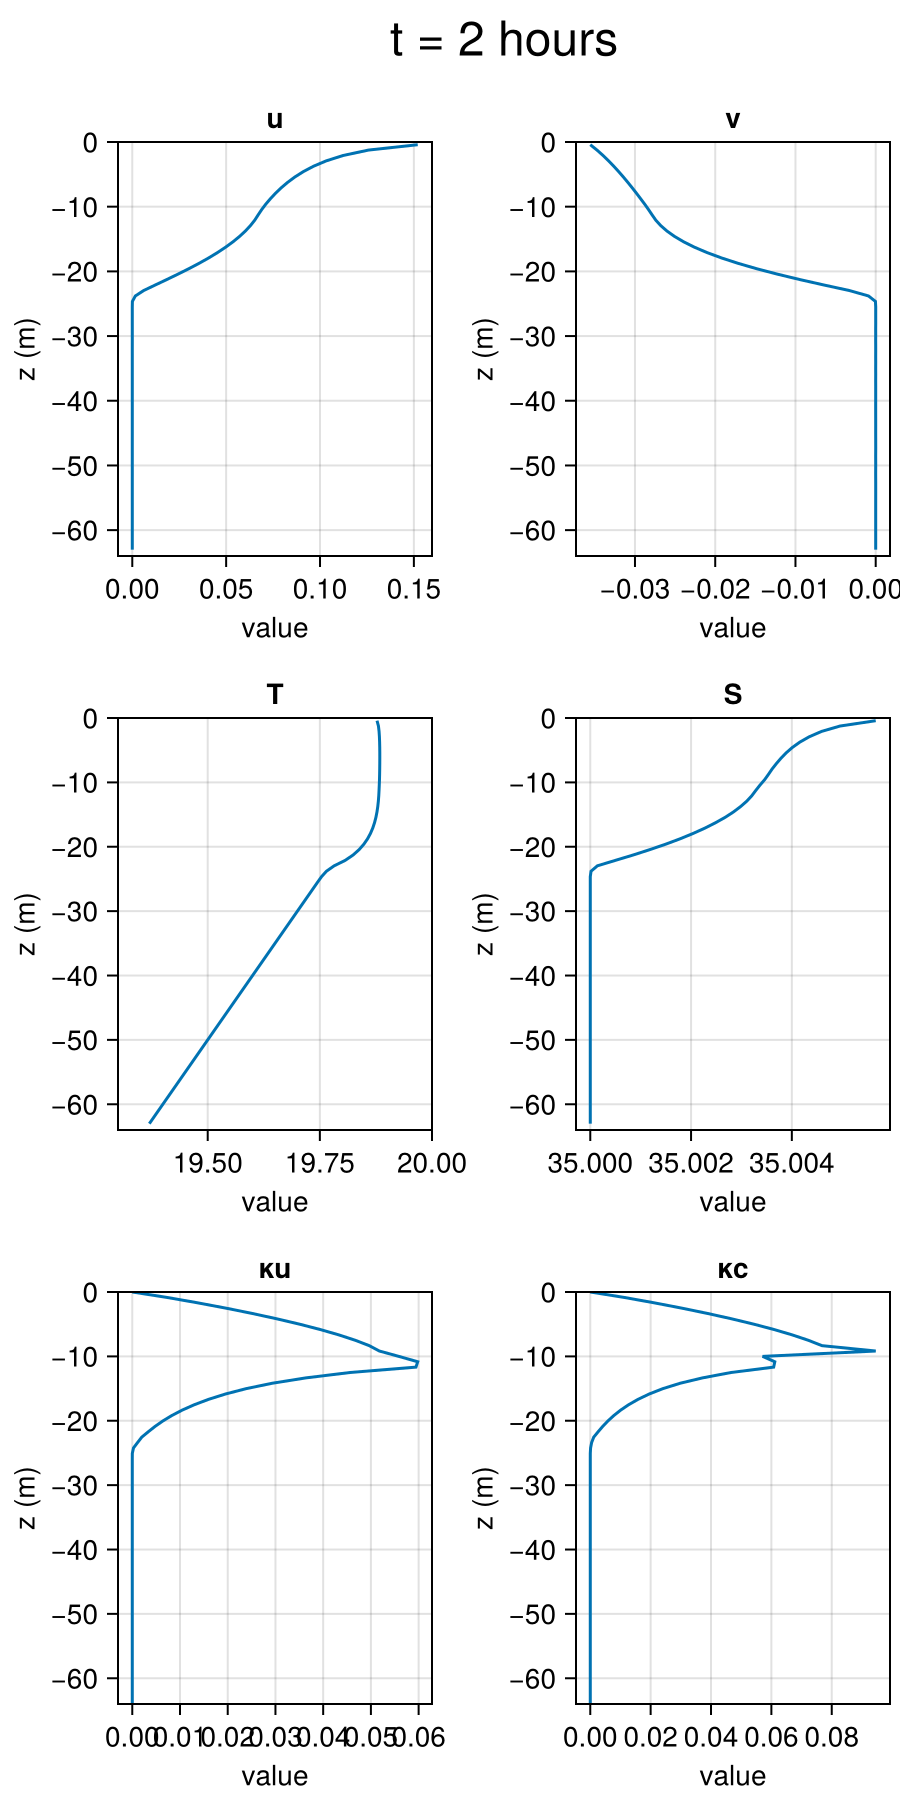

In [21]:
times = time_series.u.times
n = Observable(length(times))



 uₙ = @lift Array(interior(time_series.u[$n], 1, 1, :))
 vₙ = @lift Array(interior(time_series.v[$n], 1, 1, :))
 Tₙ = @lift Array(interior(time_series.T[$n], 1, 1, :))
 Sₙ = @lift Array(interior(time_series.S[$n], 1, 1, :))
κuₙ = @lift Array(interior(time_series.κu[$n], 1, 1, :))
κcₙ = @lift Array(interior(time_series.κc[$n], 1, 1, :))

zc = znodes(grid, Center())
zf = znodes(grid, Face())



fig = Figure(size = (450, 900), figure_padding = 5)

axis_kwargs = (xlabel = "value",
               ylabel = "z (m)",
               limits = (nothing, (-grid.Lz, 0)))

ax_u  = Axis(fig[1, 1]; title = "u",  axis_kwargs...)
ax_v  = Axis(fig[1, 2]; title = "v",  axis_kwargs...)
ax_T  = Axis(fig[2, 1]; title = "T",  axis_kwargs...)
ax_S  = Axis(fig[2, 2]; title = "S",  axis_kwargs...)
ax_κu = Axis(fig[3, 1]; title = "κu", axis_kwargs...)
ax_κc = Axis(fig[3, 2]; title = "κc", axis_kwargs...)

title = @lift @sprintf("t = %s", prettytime(times[$n]))

lines!(ax_u,  uₙ,  zc)
lines!(ax_v,  vₙ,  zc)
lines!(ax_T,  Tₙ,  zc)
lines!(ax_S,  Sₙ,  zc)
lines!(ax_κu, κuₙ, zf)
lines!(ax_κc, κcₙ, zf)

xlims!(ax_T, 19.3,20)

fig[0, 1:2] = Label(fig, title, fontsize=24, tellwidth=false)

fig

In [22]:
intro = searchsortedfirst(times, 10minutes)
frames = intro:length(times)

@info "Making a motion picture of ocean wind mixing and convection..."

resize_to_layout!(fig)

CairoMakie.record(fig, filename * ".mp4", frames, framerate=8) do i
    n[] = i
end

[ Info: Making a motion picture of ocean wind mixing and convection...


"ocean_wind_mixing_and_convection.mp4"